In [6]:
%pip install pypdf

  Using cached pypdf-6.7.3-py3-none-any.whl.metadata (7.1 kB)
Using cached pypdf-6.7.3-py3-none-any.whl (331 kB)

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install langchain-community langchain-openai

  Using cached langchain_community-0.4.1-py3-none-any.whl.metadata (3.0 kB)
  Using cached langchain_classic-1.0.1-py3-none-any.whl.metadata (4.2 kB)
  Using cached sqlalchemy-2.0.47-cp313-cp313-macosx_11_0_arm64.whl.metadata (9.5 kB)
  Using cached aiohttp-3.13.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (8.1 kB)
  Using cached dataclasses_json-0.6.7-py3-none-any.whl.metadata (25 kB)
  Using cached pydantic_settings-2.13.1-py3-none-any.whl.metadata (3.4 kB)
  Using cached httpx_sse-0.4.3-py3-none-any.whl.metadata (9.7 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached frozenlist-1.8.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (20 kB)
  Using cached multidict-6.7.1-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.3 kB)
  Using cached propcache-0.4.1-cp313-cp313-macosx_11_0_arm64.whl.metadata (13 kB)
  Using cached yarl-1.22.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (75 kB)
  Usi

In [3]:
from typing import List, TypedDict
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

True

In [7]:
docs = (
    PyPDFLoader("/Users/diliprtandekar/Documents/Langgraphtutorials/chatbot-in-langgraph-main/book1.pdf").load() +
    PyPDFLoader("/Users/diliprtandekar/Documents/Langgraphtutorials/chatbot-in-langgraph-main/book2.pdf").load() +
    PyPDFLoader("/Users/diliprtandekar/Documents/Langgraphtutorials/chatbot-in-langgraph-main/book3.pdf").load()
)

In [8]:
len(docs)

2123

In [9]:
# 2) Chunk
chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)

# 3) Clean text to avoid UnicodeEncodeError (surrogates from PDF extraction)
for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

In [10]:
len(chunks)

6396

In [12]:
# 3) Index (fresh collection each run)
embeddings = OpenAIEmbeddings(model='text-embedding-3-large')
vector_store = FAISS.from_documents(chunks, embeddings)

In [13]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [14]:
# 4) LLM + prompt
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [15]:
class State(TypedDict):
    question: str
    docs: List[Document]
    answer: str

In [16]:
def retrieve(state):
    q = state["question"]
    return {"docs": retriever.invoke(q)}

In [17]:

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "Answer only from the context. If not in context, say you don't know."),
        ("human", "Question: {question}\n\nContext:\n{context}"),
    ]
)
def generate(state):
    context = "\n\n".join(d.page_content for d in state["docs"])
    out = (prompt | llm).invoke({"question": state["question"], "context": context})
    return {"answer": out.content}


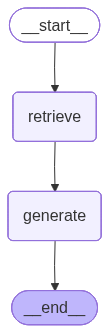

In [19]:
g = StateGraph(State)
g.add_node("retrieve", retrieve)
g.add_node("generate", generate)
g.add_edge(START, "retrieve")
g.add_edge("retrieve", "generate")
g.add_edge("generate", END)
app = g.compile()

app

In [20]:
# 5) Run
res = app.invoke({"question": "WHat is a transformer in deep learning.", "docs": [], "answer": ""})
print(res["answer"])

The context does not provide a definition or explanation of a transformer in deep learning. Therefore, I don't know.


In [21]:
print(res['docs'][0].page_content)
print('*'*100)
print(res['docs'][1].page_content)
print('*'*100)
print(res['docs'][2].page_content)
print('*'*100)
print(res['docs'][3].page_content)

ducingrepresentationsthatareexpressedintermsofother,simplerrepresentations.
Deeplearningallowsthecomputertobuildcomplexconceptsoutofsimplercon-
cepts.Figureshowshowadeeplearningsystemcanrepresenttheconceptof1.2
animageofapersonbycombiningsimplerconcepts,suchascornersandcontours,
whichareinturndeﬁnedintermsofedges.
Thequintessentialexampleofadeeplearningmodelisthefeedforwarddeep
networkormultilayerperceptron(MLP).Amultilayerperceptronisjusta
mathematicalfunctionmappingsomesetofinputvaluestooutputvalues.The
functionisformedbycomposingmanysimplerfunctions.Wecanthinkofeach
applicationofadiﬀerentmathematicalfunctionasprovidinganewrepresentation
oftheinput.
Theideaoflearningtherightrepresentationforthedataprovidesoneperspec-
tiveondeeplearning.Anotherperspectiveondeeplearningisthatdepthallowsthe
computertolearnamulti-stepcomputerprogram.Eachlayeroftherepresentation
****************************************************************************************************
6 A convolution is a mathem